In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv('hotel_bookings.csv')

In [ ]:
df.head()

In [19]:
print("Data Description")
print(df.info())

Data Description
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12 

In [20]:
print("Statistical Description")
print(df.describe())

Statistical Description
         is_canceled      lead_time  arrival_date_year  \
count  119390.000000  119390.000000      119390.000000   
mean        0.370416     104.011416        2016.156554   
std         0.482918     106.863097           0.707476   
min         0.000000       0.000000        2015.000000   
25%         0.000000      18.000000        2016.000000   
50%         0.000000      69.000000        2016.000000   
75%         1.000000     160.000000        2017.000000   
max         1.000000     737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count             119390.000000              119390.000000   
mean                  27.165173                  15.798241   
std                   13.605138                   8.780829   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   28.000000                  16.000000   
75%                

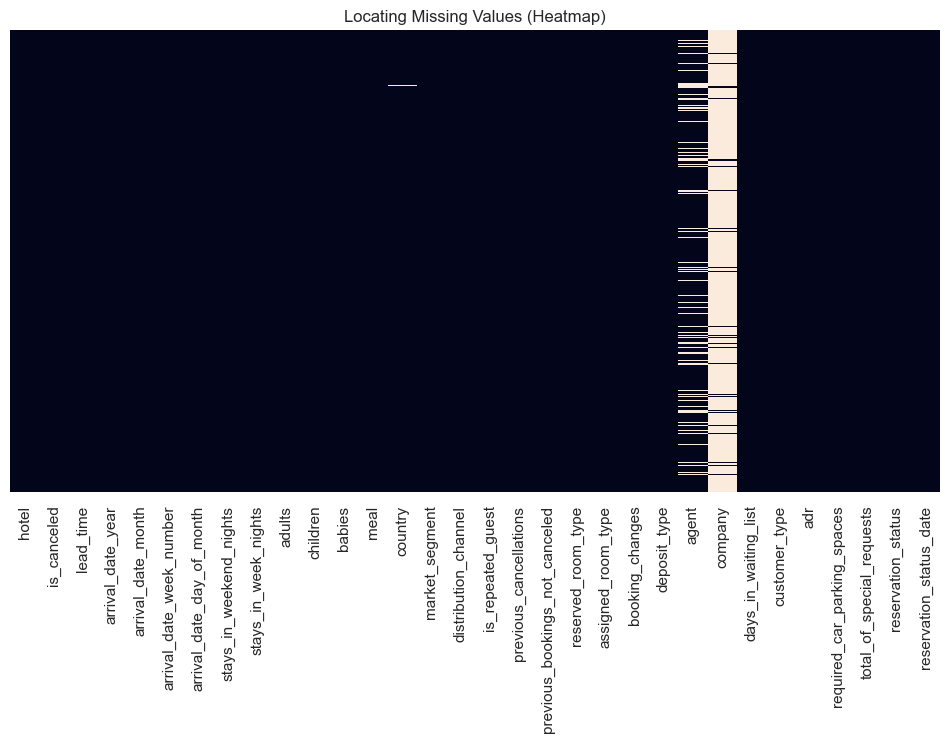

In [21]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='rocket')
plt.title('Locating Missing Values (Heatmap)')
plt.show()

In [22]:
df['children'] = df['children'].fillna(df['children'].median())
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

### Justification for Handling Missing Data

**1. children column (Missing: 4 values)**
- **Method used**: Median 
- **Justification**: Only 4 missing values out of 119,390 rows. Median is better than mean because it's not affected by outliers in children count.

**2. country column (Missing: 488 values)**
- **Method used**: Filled with 'Unknown'
- **Justification**: Country is categorical data, so mean/median can't be used. Deleting rows would remove useful data. Adding 'Unknown' keeps all data while clearly marking missing values.

**3. agent column (Missing: 16,340 values)**
- **Method used**: Filled with 0
- **Justification**: Agent numbers represent travel agencies. 0 means "no agent" (direct booking), which makes practical sense since many bookings are direct.

**4. company column (Missing: 112,593 values)**
- **Method used**: Filled with 0
- **Justification**: ~94% of values are missing. Deleting would remove most data. Mean/median not applicable for categorical data. 0 represents "no company" (individual bookings).

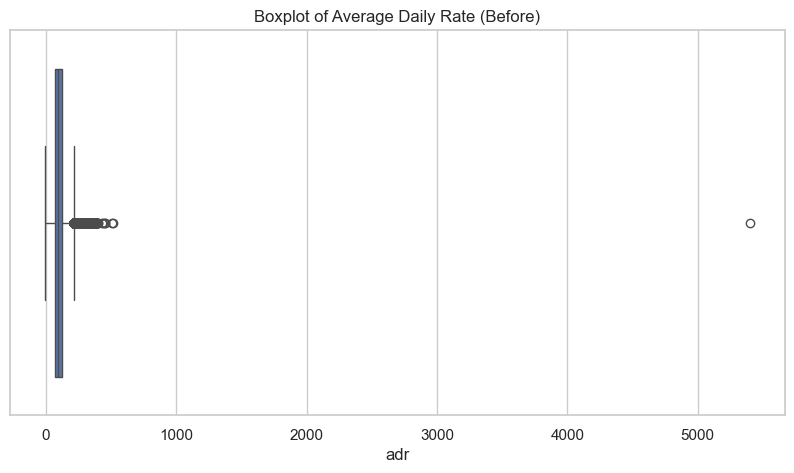

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['adr'])
plt.title('Boxplot of Average Daily Rate (Before)')
plt.show()

In [24]:
df = df[df['adr'] < 5000] 
df = df[df['adr'] >= 0]

In [25]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR



In [26]:
df_cleaned = df[(df['adr'] >= lower_bound) & (df['adr'] <= upper_bound)]

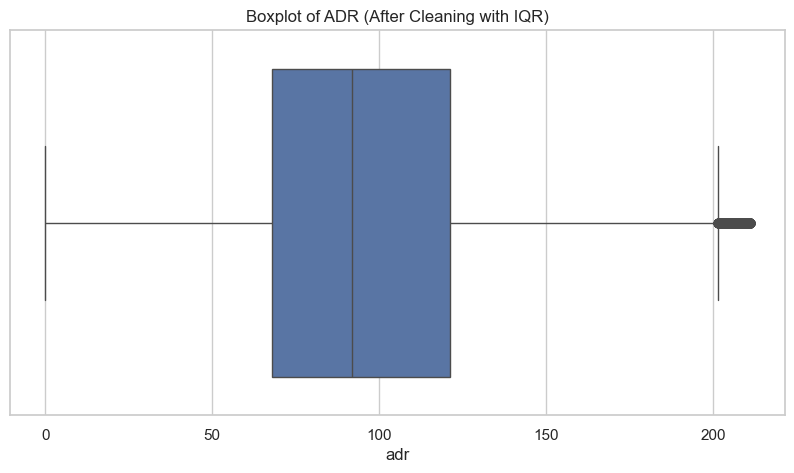

In [27]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_cleaned['adr'])
plt.title('Boxplot of ADR (After Cleaning with IQR)')
plt.show()

In [45]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['hotel'], drop_first=True)

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_cleaned['adr_scaled'] = scaler.fit_transform(df_cleaned[['adr']])

In [47]:
df_final = df_cleaned.copy()

month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6, 
             'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12}


df_final['arrival_date_month_num'] = df_final['arrival_date_month'].map(month_map).fillna(df_final['arrival_date_month'])


df_final['arrival_date_month_num'] = df_final['arrival_date_month_num'].fillna(1).astype(int)


df_final['arrival_date'] = pd.to_datetime(dict(
    year=df_final['arrival_date_year'], 
    month=df_final['arrival_date_month_num'], 
    day=df_final['arrival_date_day_of_month']
))


df_final['reservation_status_date'] = pd.to_datetime(df_final['reservation_status_date'])

display(df_final[['arrival_date', 'arrival_date_month', 'arrival_date_year']].head())


,arrival_date,arrival_date_month,arrival_date_year
0,2015-07-01,July,2015
1,2015-07-01,July,2015
2,2015-07-01,July,2015
3,2015-07-01,July,2015
4,2015-07-01,July,2015


cleaning_summary


,Column,Before Cleaning,After Cleaning
0,children,4 Nulls,0 Nulls (Filled with Median)
1,country,488 Nulls,0 Nulls (Filled with Unknown)
2,agent,"16,340 Nulls",0 Nulls (Filled with 0)
3,company,"112,593 Nulls",0 Nulls (Filled with 0)
4,adr (Outliers),Includes Negative/5400,Handled with IQR


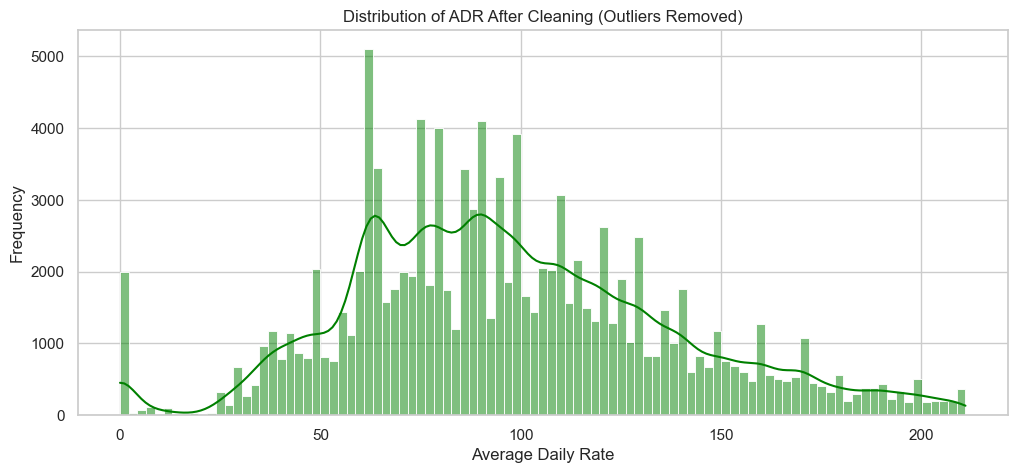

In [48]:
cleaning_summary = pd.DataFrame({
    'Column': ['children', 'country', 'agent', 'company', 'adr (Outliers)'],
    'Before Cleaning': ['4 Nulls', '488 Nulls', '16,340 Nulls', '112,593 Nulls', 'Includes Negative/5400'],
    'After Cleaning': ['0 Nulls (Filled with Median)', '0 Nulls (Filled with Unknown)', '0 Nulls (Filled with 0)', '0 Nulls (Filled with 0)', 'Handled with IQR']
})

print("cleaning_summary")
display(cleaning_summary)


plt.figure(figsize=(12, 5))
sns.histplot(df_final['adr'], kde=True, color='green')
plt.title('Distribution of ADR After Cleaning (Outliers Removed)')
plt.xlabel('Average Daily Rate')
plt.ylabel('Frequency')
plt.show()


In [49]:
df_final.to_csv('Cleaned Data.csv', index=False)

print("Data Cleaned Successfully ")

Data Cleaned Successfully 


# Task 3: EDA & Feature Engineering

## 1. Data Visualization (EDA)

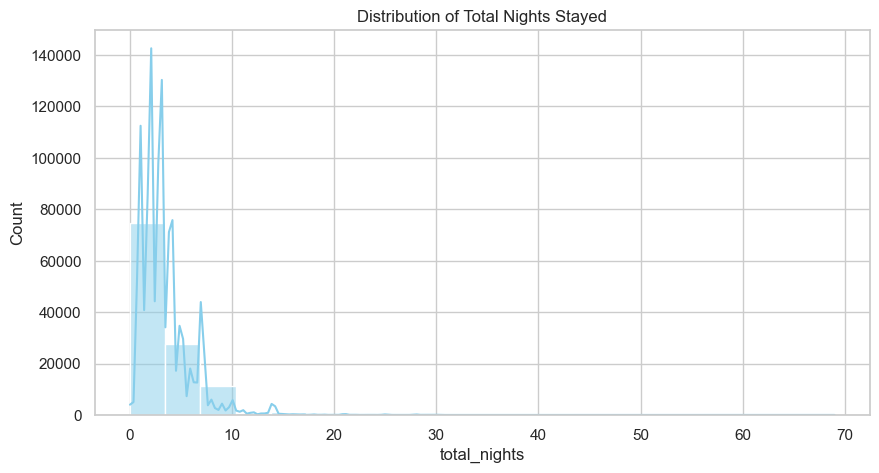

In [32]:
# 1. Distribution Plot
plt.figure(figsize=(10, 5))
df_final['total_nights'] = df_final['stays_in_weekend_nights'] + df_final['stays_in_week_nights']
sns.histplot(df_final['total_nights'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Total Nights Stayed')
plt.show()

**Interpretation:** The histogram shows that most guests stay for a short period (1–4 nights). 
This indicates that the hotels are primarily used for short trips or city tourism rather than long vacations.

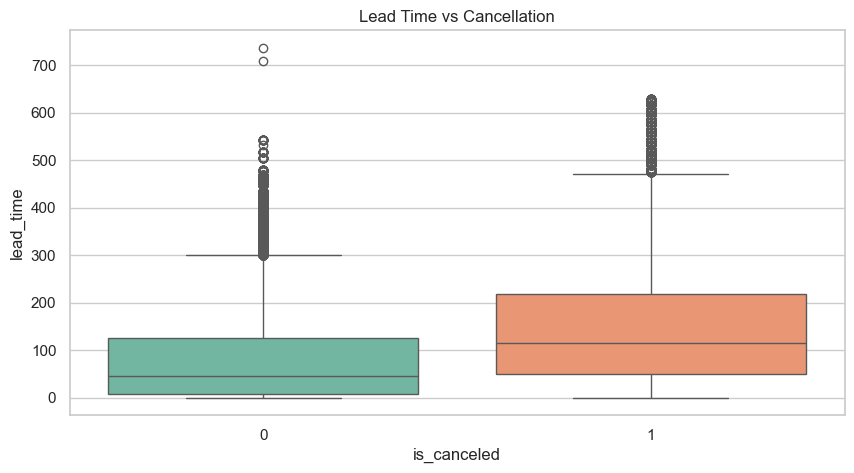

In [34]:
# 2. Relationship Plot 
plt.figure(figsize=(10, 5))
sns.boxplot(x='is_canceled', y='lead_time', data=df_final, hue='is_canceled', palette='Set2', legend=False)
plt.title('Lead Time vs Cancellation')
plt.show()

**Interpretation:** The boxplot reveals that canceled bookings tend to have a higher "Lead Time." This suggests that the further in advance a booking is made, the more likely it is to be canceled.

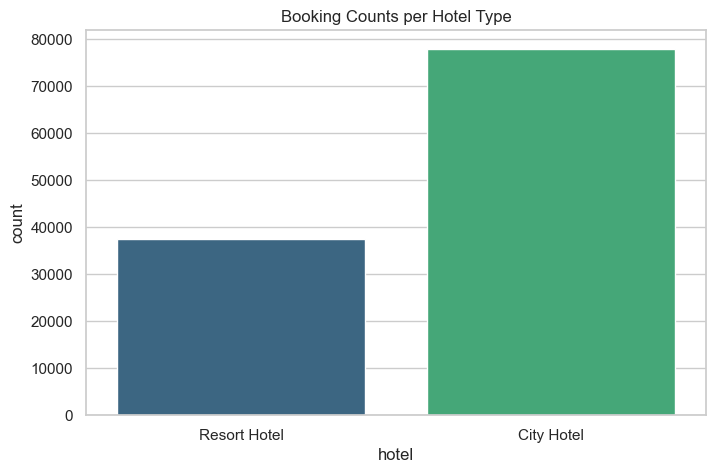

In [35]:
# 3. Comparison Plot 
plt.figure(figsize=(8, 5))
sns.countplot(x='hotel', data=df_final, hue='hotel', palette='viridis', legend=False)
plt.title('Booking Counts per Hotel Type')
plt.show()

**Interpretation:** The bar chart shows that "City Hotels" receive significantly more bookings than "Resort Hotels," making them the primary driver of demand in this dataset.


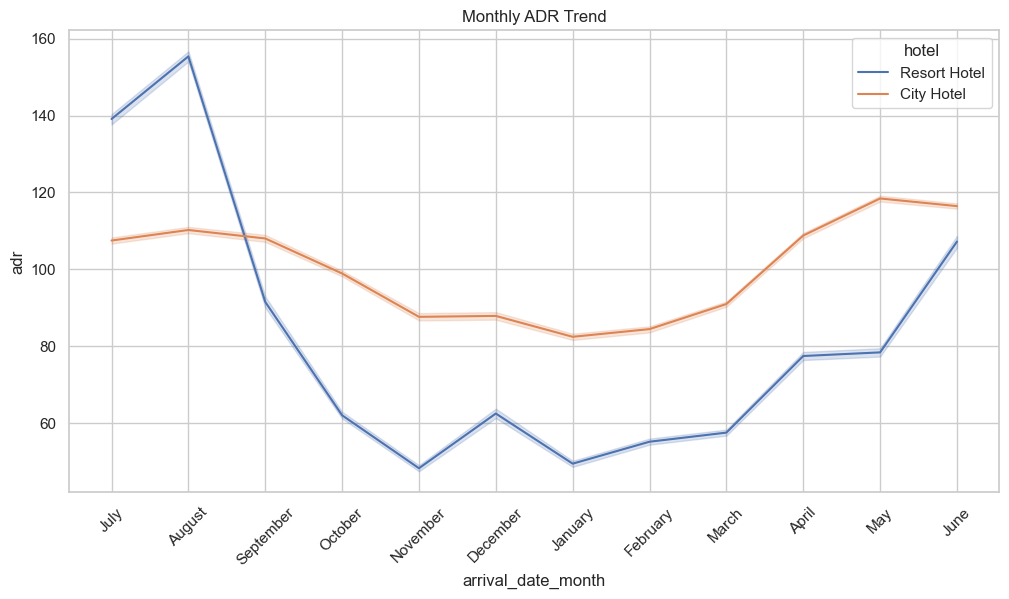

In [36]:
# 4. Trend Plot
plt.figure(figsize=(12, 6))
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
sns.lineplot(x='arrival_date_month', y='adr', data=df_final, hue='hotel', hue_order=['Resort Hotel', 'City Hotel'])
plt.xticks(rotation=45)
plt.title('Monthly ADR Trend')
plt.show()

**Interpretation:** The line chart highlights a clear seasonal trend. Resort Hotel prices peak in July and August (summer season), while City Hotel prices remain relatively stable throughout the year.


## 2. Feature Engineering

In [37]:
df_final['total_guests'] = df_final['adults'] + df_final['children'] + df_final['babies']

def get_traveler_type(row):
    if row['total_guests'] == 1:
        return 'Single'
    elif row['total_guests'] == 2:
        return 'Couple'
    else:
        return 'Family/Group'

df_final['traveler_type'] = df_final.apply(get_traveler_type, axis=1)

print("Features Created:")
print(df_final[['total_guests', 'traveler_type']].head())

Features Created:
   total_guests traveler_type
0           2.0        Couple
1           2.0        Couple
2           1.0        Single
3           1.0        Single
4           2.0        Couple


In this step, I created two new features to enhance the analysis:

1. **`total_guests`**: A combination of adults, children, and babies. 
   - *Purpose:* Helps in understanding the total capacity required per booking and its impact on price.
2. **`traveler_type`**: Categorizes bookings into 'Single', 'Couple', or 'Family/Group' based on the total guests.
   - *Purpose:* Helps in identifying the most common types of bookings (Families vs. Individuals) as requested in the project goals.